# Tarea 2: Predicción de redshift fotométrico con métodos de ensamble

## Contexto

El redshift de una galaxia es una cantidad fundamental para estudiar distancias cosmológicas y evolución de galaxias. Idealmente, el redshift se mide mediante espectroscopía, pero obtener espectros para grandes muestras puede ser costoso en tiempo de observación.

Una alternativa ampliamente usada en astronomía es estimar redshifts fotométricos a partir de magnitudes medidas en distintos filtros. En esta actividad trabajaremos con un catálogo de galaxias que contiene fotometría multibanda y redshifts espectroscópicos de referencia. El objetivo será entrenar modelos de machine learning capaces de predecir el redshift usando información fotométrica.

La actividad se plantea como una competencia tipo **Kaggle**: cada grupo entrenará sus modelos con un conjunto de entrenamiento y deberá generar predicciones para un conjunto de test oculto. El ranking final se calculará usando el MSE sobre ese conjunto de test.

---

## Objetivo

Entrenar, comparar y optimizar modelos de regresión basados en árboles y métodos de ensamble para predecir el redshift de galaxias.

El criterio principal de evaluación será el error cuadrático medio:

$$
MSE = \frac{1}{N}\sum_i (z_{{\rm pred},i} - z_{{\rm true},i})^2
$$

El objetivo práctico será obtener el menor MSE posible en el conjunto de test oculto.

---

## Datos

Se entregarán tres archivos:

1. `train_redshift.csv`: contiene las variables fotométricas y el redshift de referencia.
2. `test_redshift.csv`: contiene las mismas variables fotométricas, pero no incluye el redshift.
3. `sample_submission.csv`: muestra el formato esperado para la entrega de predicciones.

El archivo de entrenamiento contiene magnitudes corregidas por apertura en distintos filtros. El redshift de referencia está en la columna: $z_{\rm helio}$

En el archivo de test, esta columna no estará disponible.

---

## Instrucciones generales

Deben desarrollar un notebook reproducible en Python que incluya:

1. Exploración inicial del conjunto de entrenamiento.
2. Preparación de los datos para modelamiento.
3. Construcción o selección de variables predictoras.
4. Separación interna entre entrenamiento y validación, o uso de validación cruzada.
5. Entrenamiento de un modelo baseline con `DecisionTreeRegressor`.
6. Entrenamiento de algún método de ensamble, por ejemplo:

   * `RandomForestRegressor`
   * `ExtraTreesRegressor`
   * `GradientBoostingRegressor`
   * `HistGradientBoostingRegressor`
   * otro método justificado.
7. Optimización de hiperparámetros.
8. Comparación de modelos usando MSE.
9. Selección del modelo final.
10. Generación de predicciones para `test_redshift.csv`.

El catálogo entregado no está completamente procesado. Parte del trabajo consiste en revisar valores faltantes, valores anómalos y decidir qué variables utilizar o construir.

El conjunto de test no contiene el redshift verdadero. Por lo tanto, no puede ser usado para evaluar ni ajustar modelos. La selección de modelos e hiperparámetros debe realizarse usando únicamente el conjunto de entrenamiento.

---

## Entrega de predicciones

Cada grupo debe entregar un archivo llamado:

```text
predicciones.csv
```

con exactamente dos columnas:

| objno_deep2 | z_pred |
| ----------- | ------ |
|             |        |
|             |        |
|             |        |

La columna `objno_deep2` debe coincidir con los identificadores del archivo `test_redshift.csv`.

La columna `z_pred` debe contener el redshift predicho por el modelo final.

El archivo debe tener una predicción para cada objeto del conjunto de test.

El archivo `sample_submission.csv` muestra el formato exacto que debe tener la entrega final. Deben reemplazar los valores de la columna `z_pred` por las predicciones de su modelo, manteniendo los mismos identificadores `objno_deep2`.

---
## Métricas de evaluación

La métrica principal de la competencia será el error cuadrático medio:

$$
MSE = \frac{1}{N}\sum_i (z_{{\rm pred},i} - z_{{\rm spec},i})^2
$$

Además, deberán reportar dos métricas comúnmente usadas en estudios de redshifts fotométricos.

Primero, definimos el residuo normalizado:

$$
\Delta z_i = \frac{z_{{\rm spec},i} - z_{{\rm pred},i}}{1 + z_{{\rm spec},i}}
$$

La dispersión robusta de los residuos se calculará mediante la normalized median absolute deviation:

$$
\sigma_{\rm NMAD} = 1.48 \times {\rm median}\left(
\left| \Delta z_i - {\rm median}(\Delta z) \right|
\right)
$$

También se calculará la fracción de outliers:

$$
\eta = \frac{N_{\rm outliers}}{N}
$$

donde se considera outlier a todo objeto que cumple:

$$
\frac{|z_{\rm spec} - z_{\rm pred}|}{1 + z_{\rm spec}} > 0.15
$$

El ranking de la competencia se calculará usando el MSE sobre el conjunto de test oculto. Sin embargo, en el notebook deben reportar e interpretar las tres métricas: MSE, $\sigma_{\rm NMAD}$ y $\eta$.



## Resultado esperado en el notebook

El notebook debe incluir una tabla resumen similar a la siguiente:

| Modelo        | Features usadas | Hiperparámetros principales | MSE train | MSE validación |
| ------------- | --------------- | --------------------------- | --------- | -------------- |
| Decision Tree |                 |                             |           |                |
| Ensemble      |                 |                             |           |                |

Además, deben incluir:

* un gráfico de $z_{\rm true}$ vs. $z_{\rm pred}$ usando datos de validación
* un análisis de los errores del modelo
* un análisis de las métricas obtenidas
* una discusión sobre las variables más relevantes
* una conclusión justificando el modelo final escogido

---

## Preguntas finales

Respondan brevemente al final del notebook:

1. ¿Qué modelo obtuvo el menor MSE en validación?
2. ¿Ese modelo fue elegido como modelo final? Justifiquen.
3. ¿Qué diferencias observaron entre un árbol individual y los métodos de ensamble?
4. ¿Qué variables parecen ser más importantes para predecir el redshift?
5. ¿En qué rangos de redshift falla más el modelo?
6. ¿Qué posibles fuentes de error o sesgo puede tener este enfoque?
7. ¿Qué decisión metodológica tuvo mayor impacto en el resultado final?
8. ¿El modelo con menor MSE es necesariamente el mejor modelo desde el punto de vista científico? Justifiquen.

---

## Restricciones importantes

No se permite usar información externa al archivo entregado para predecir el redshift del conjunto de test.

No se debe modificar manualmente el archivo de predicciones para objetos individuales.

No se debe usar el conjunto de test para ajustar hiperparámetros ni tomar decisiones de modelamiento. El test oculto se usará solo para la evaluación final.

---

## Entregables

Cada grupo debe entregar:

1. Notebook reproducible en Python.
2. Archivo `predicciones.csv` con las predicciones para el conjunto de test.
3. Breve conclusión final dentro del notebook.

La evaluación considerará tanto el desempeño predictivo como la calidad del procedimiento. El ranking se calculará usando el MSE sobre el conjunto de test oculto, pero la nota no dependerá únicamente del ranking.


In [37]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, HistGradientBoostingRegressor
from sklearn.model_selection import KFold, cross_val_score, RandomizedSearchCV
from sklearn.metrics import mean_squared_error
from sklearn.inspection import permutation_importance

import warnings
warnings.filterwarnings('ignore')

SEED = 42
P = {'blue':'#7c9df7','orange':'#f7a27c','green':'#7cf7c4',
     'purple':'#a78bfa','yellow':'#fbbf24','red':'#f87171'}

from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
train = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/Machine Learning/Tarea 2/train_redshift.csv')
test = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/Machine Learning/Tarea 2/test_redshift.csv')
sample = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/Machine Learning/Tarea 2/sample_submission.csv')

print(f"Train: {train.shape}   Test: {test.shape}")
print(f"\nColumnas train: {list(Train.columns)}")
Train.head(3)

Train: (19057, 14)   Test: (4765, 13)

Columnas train: ['objno_deep2', 'ra_deep2', 'dec_deep2', 'zquality', 'u_apercor', 'g_apercor', 'r_apercor', 'i_apercor', 'i2_apercor', 'z_apercor', 'flag_cfhtls', 'cfhtls_source', 'subaru_source', 'zhelio']


,objno_deep2,ra_deep2,dec_deep2,zquality,u_apercor,g_apercor,r_apercor,i_apercor,i2_apercor,z_apercor,flag_cfhtls,cfhtls_source,subaru_source,zhelio
0,13027624,214.812895,52.987945,1,25.536802,25.462694,25.331811,24.767236,24.867649,24.539227,0,0,-99,1.664840
1,12020064,214.693819,52.637015,4,23.802174,23.591218,23.290410,22.990565,23.018509,22.496892,0,0,0,1.314826
2,13035227,214.994798,53.051865,4,23.661166,22.389709,21.359927,20.786062,20.839287,20.466936,0,0,-99,0.297696


---
## 2. EDA

### 2.1 Centinelas y datos faltantes

Los catálogos fotométricos usan `-99` (no detección) y `99` (saturación) como centinelas — no son NaN reales pero deben tratarse como datos faltantes.

In [ ]:
print("=== DTYPES ===")
print(Train.dtypes)
print("\n=== MISSING VALUES ===")
print(Train.isnull().sum())

=== DTYPES ===
objno_deep2        int64
ra_deep2         float64
dec_deep2        float64
zquality           int64
u_apercor        float64
g_apercor        float64
r_apercor        float64
i_apercor        float64
i2_apercor       float64
z_apercor        float64
flag_cfhtls        int64
cfhtls_source      int64
subaru_source      int64
zhelio           float64
dtype: object

=== MISSING VALUES ===
objno_deep2      0
ra_deep2         0
dec_deep2        0
zquality         0
u_apercor        0
g_apercor        0
r_apercor        0
i_apercor        0
i2_apercor       0
z_apercor        0
flag_cfhtls      0
cfhtls_source    0
subaru_source    0
zhelio           0
dtype: int64


In [ ]:
MAGS = ['u_apercor','g_apercor','r_apercor','i_apercor','i2_apercor','z_apercor']

sentinel_info = pd.DataFrame({
    'NaN reales':  train[MAGS].isnull().sum(),
    'Centinela -99': [(train[c] == -99).sum() for c in MAGS],
    'Centinela +99': [(train[c] == 99).sum()  for c in MAGS],
}, index=[c.replace('_apercor','') for c in MAGS])
sentinel_info['Total faltante'] = sentinel_info.sum(axis=1)
sentinel_info['% faltante']     = (sentinel_info['Total faltante'] / len(train) * 100).round(1)
print(sentinel_info)

    NaN reales  Centinela -99  Centinela +99  Total faltante  % faltante
u          NaN            439            396           835.0         4.4
g          NaN            439            285           724.0         3.8
r          NaN            439            282           721.0         3.8
i          NaN            439            286           725.0         3.8
i2         NaN           7230            119          7349.0        38.6
z          NaN            439            287           726.0         3.8


### 2.2 Target `zhelio` y calidad espectroscópica

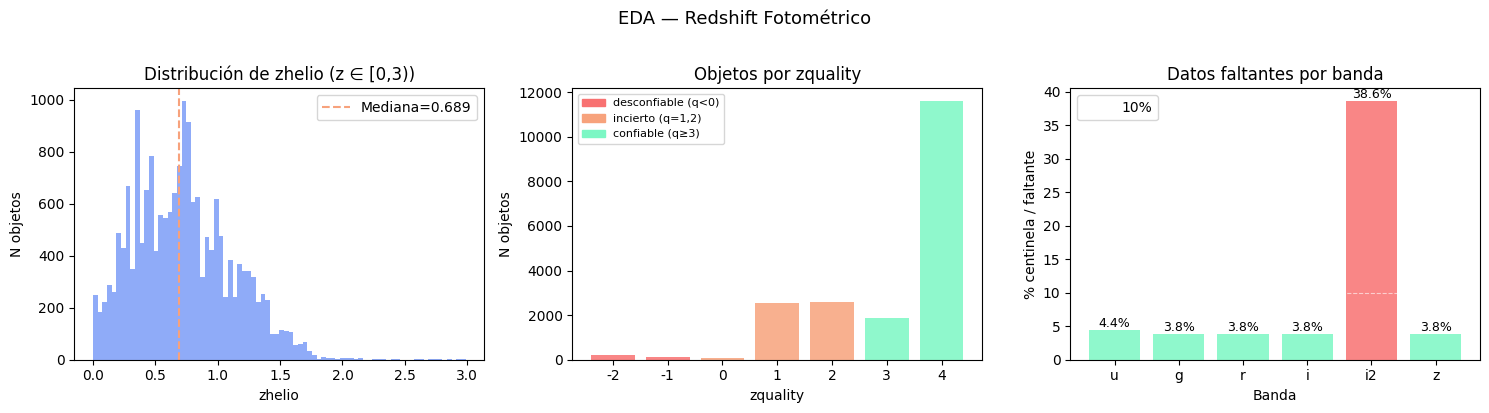


zhelio — min:-0.0785  max:4.5006  negativos:334  z>2:81
zquality=-1 tiene z≈0 artificial (0.00074 std)


In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# 1. Distribución zhelio
ax = axes[0]
z = Train['zhelio']
ax.hist(z[(z >= 0) & (z < 3)], bins=80, color=P['blue'], edgecolor='none', alpha=0.85)
ax.axvline(z.median(), color=P['orange'], lw=1.5, linestyle='--',
           label=f'Mediana={z.median():.3f}')
ax.set_xlabel('zhelio')
ax.set_ylabel('N objetos')
ax.set_title('Distribución de zhelio (z ∈ [0,3))')
ax.legend()

# 2. Conteo por zquality
ax = axes[1]
vc = Train['zquality'].value_counts().sort_index()
colors_q = [P['red'] if q < 0 else P['orange'] if q <= 2 else P['green']
            for q in vc.index]
ax.bar([str(q) for q in vc.index], vc.values, color=colors_q, edgecolor='none', alpha=0.85)
ax.set_xlabel('zquality')
ax.set_ylabel('N objetos')
ax.set_title('Objetos por zquality')
from matplotlib.patches import Patch
ax.legend(handles=[
    Patch(color=P['red'],    label='desconfiable (q<0)'),
    Patch(color=P['orange'], label='incierto (q=1,2)'),
    Patch(color=P['green'],  label='confiable (q≥3)'),
], fontsize=8)

# 3. % datos faltantes por banda
ax = axes[2]
pct = sentinel_info['% faltante']
bars = ax.bar(pct.index, pct.values,
              color=[P['red'] if v > 10 else P['green'] for v in pct.values],
              edgecolor='none', alpha=0.85)
ax.axhline(10, color='white', lw=0.8, linestyle='--', alpha=0.6, label='10%')
for bar, v in zip(bars, pct.values):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.5,
            f'{v}%', ha='center', fontsize=9)
ax.set_xlabel('Banda')
ax.set_ylabel('% centinela / faltante')
ax.set_title('Datos faltantes por banda')
ax.legend()

plt.suptitle('EDA — Redshift Fotométrico', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

print(f"\nzhelio — min:{z.min():.4f}  max:{z.max():.4f}  negativos:{(z<0).sum()}  z>2:{(z>2).sum()}")
print(f"zquality=-1 tiene z≈0 artificial ({train[train['zquality']==-1]['zhelio'].std():.5f} std)")

### 2.3 Correlaciones: magnitudes y colores vs zhelio

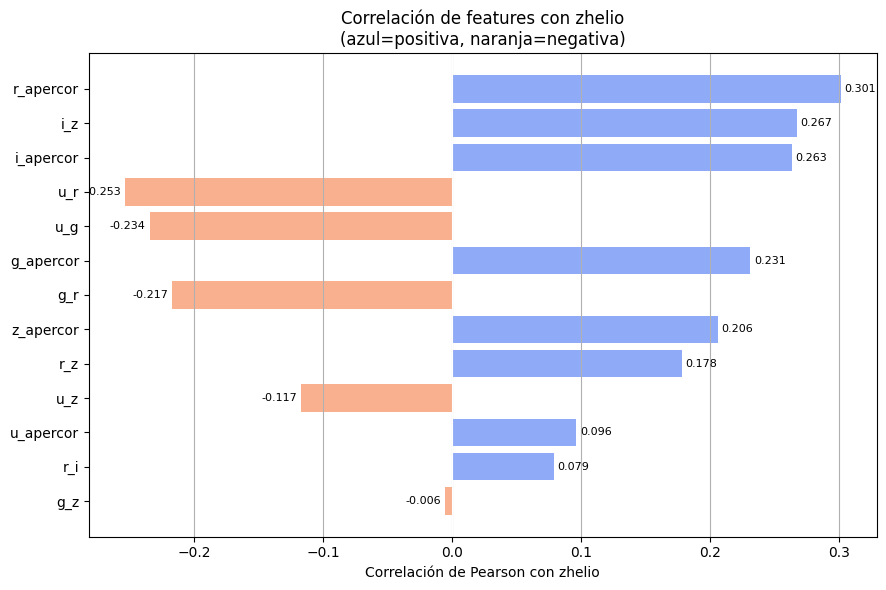

In [31]:
# Calcular colores temporalmente para el EDA
tmp = train.copy()
for col in MAGS:
    tmp[col] = tmp[col].replace([-99, 99], np.nan)

tmp['u_g'] = tmp['u_apercor'] - tmp['g_apercor']
tmp['g_r'] = tmp['g_apercor'] - tmp['r_apercor']
tmp['r_i'] = tmp['r_apercor'] - tmp['i_apercor']
tmp['i_z'] = tmp['i_apercor'] - tmp['z_apercor']
tmp['u_r'] = tmp['u_apercor'] - tmp['r_apercor']
tmp['g_z'] = tmp['g_apercor'] - tmp['z_apercor']
tmp['r_z'] = tmp['r_apercor'] - tmp['z_apercor']
tmp['u_z'] = tmp['u_apercor'] - tmp['z_apercor']

features_eda = ['u_apercor','g_apercor','r_apercor','i_apercor','z_apercor',
                'u_g','g_r','r_i','i_z','u_r','g_z','r_z','u_z']

corrs = {}
for f in features_eda:
    mask = tmp[f].notna() & tmp['zhelio'].notna() & (tmp[f].abs() < 50)
    r, _ = stats.pearsonr(tmp.loc[mask, f], tmp.loc[mask, 'zhelio'])
    corrs[f] = r

corr_s = pd.Series(corrs).sort_values(key=abs, ascending=True)

fig, ax = plt.subplots(figsize=(9, 6))
colors_b = [P['blue'] if v > 0 else P['orange'] for v in corr_s]
ax.barh(corr_s.index, corr_s.values, color=colors_b, edgecolor='none', alpha=0.85)
ax.axvline(0, color='white', lw=0.8)
for i, (name, val) in enumerate(corr_s.items()):
    ax.text(val + (0.003 if val > 0 else -0.003), i,
            f'{val:.3f}', va='center', ha='left' if val > 0 else 'right', fontsize=8)
ax.set_xlabel('Correlación de Pearson con zhelio')
ax.set_title('Correlación de features con zhelio\n(azul=positiva, naranja=negativa)')
ax.grid(axis='x')
plt.tight_layout()
plt.show()

**Observaciones EDA:**
- La banda `i2` tiene ~38.6% de datos centinela → se incluye pero se necesita un modelo que tolere NaN.
- `zquality < 0` contiene redshifts espurios (z≈0 artificial) → filtrar en training.
- Los **colores** (`i_z`, `u_r`, `u_g`) son más informativos que las magnitudes brutas.
- Se filtrará el training a `zquality ≥ 2` y `zhelio ≥ 0`.

---
## 3. Preprocesamiento

In [33]:
def preprocess(df, is_train=True):
    """
    Pipeline de preprocesamiento:
    1. Reemplaza centinelas -99/99 con NaN
    2. Construye colores fotométricos
    3. Agrega features de flags
    """
    df = df.copy()

    # 1. Centinelas → NaN
    for col in MAGS:
        df[col] = df[col].replace([-99, 99], np.nan)

    # 2. Colores fotométricos
    df['u_g']  = df['u_apercor'] - df['g_apercor']
    df['g_r']  = df['g_apercor'] - df['r_apercor']
    df['r_i']  = df['r_apercor'] - df['i_apercor']
    df['i_z']  = df['i_apercor'] - df['z_apercor']
    df['g_i']  = df['g_apercor'] - df['i_apercor']
    df['g_z']  = df['g_apercor'] - df['z_apercor']
    df['r_z']  = df['r_apercor'] - df['z_apercor']
    df['u_r']  = df['u_apercor'] - df['r_apercor']
    df['u_z']  = df['u_apercor'] - df['z_apercor']
    df['u_i']  = df['u_apercor'] - df['i_apercor']

    # 3. Flag de origen (binario: tiene medición de Subaru o CFHTLS)
    df['has_cfhtls'] = (df['cfhtls_source'] == 1).astype(int)
    df['has_subaru'] = (df['subaru_source'] == 1).astype(int)

    return df


# Aplicar preprocesamiento
df_train_full = preprocess(train, is_train=True)
df_test       = preprocess(test,  is_train=False)

# Filtrar training: solo redshifts confiables
mask_filter = (df_train_full['zquality'] >= 2) & (df_train_full['zhelio'] >= 0)
df_train = df_train_full[mask_filter].copy()

print(f"Train original:  {len(df_train_full):>6} objetos")
print(f"Train filtrado:  {len(df_train):>6} objetos  ({len(df_train)/len(df_train_full)*100:.1f}%)")
print(f"Test:            {len(df_test):>6} objetos")

Train original:   19057 objetos
Train filtrado:   16007 objetos  (84.0%)
Test:              4765 objetos


In [34]:
# Definir features y target
FEATURES = [
    # Magnitudes
    'u_apercor', 'g_apercor', 'r_apercor', 'i_apercor', 'i2_apercor', 'z_apercor',
    # Colores
    'u_g', 'g_r', 'r_i', 'i_z', 'g_i', 'g_z', 'r_z', 'u_r', 'u_z', 'u_i',
    # Flags de fuente
    'has_cfhtls', 'has_subaru',
]

TARGET = 'zhelio'

X = df_train[FEATURES]
y = df_train[TARGET]
X_test = df_test[FEATURES]

print(f"Features: {len(FEATURES)}")
print(f"X shape: {X.shape}")
print(f"y — mean: {y.mean():.4f}  std: {y.std():.4f}  min: {y.min():.4f}  max: {y.max():.4f}")
print(f"\nNaN por feature (top):")
nan_counts = X.isnull().sum().sort_values(ascending=False)
print(nan_counts[nan_counts > 0])

Features: 18
X shape: (16007, 18)
y — mean: 0.7374  std: 0.3869  min: 0.0000  max: 4.2984

NaN por feature (top):
i2_apercor    6004
u_i            571
u_z            570
u_g            569
u_r            568
u_apercor      568
g_z            509
g_i            509
i_apercor      508
r_i            508
i_z            508
g_apercor      507
z_apercor      507
g_r            507
r_z            507
r_apercor      505
dtype: int64


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
features, target, test_size=0.33, random_state=67)

---
## 4. Funciones de evaluación

Definimos las tres métricas del enunciado: MSE, σ_NMAD y η (fracción de outliers).

In [38]:
def sigma_nmad(y_true, y_pred):
    """Normalized Median Absolute Deviation de los residuos normalizados."""
    dz = (y_true - y_pred) / (1 + y_true)
    return 1.48 * np.median(np.abs(dz - np.median(dz)))

def eta(y_true, y_pred, threshold=0.15):
    """Fracción de outliers: |Δz_norm| > 0.15"""
    dz_norm = np.abs(y_true - y_pred) / (1 + y_true)
    return (dz_norm > threshold).mean()

def evaluate(y_true, y_pred, label=''):
    """Imprime las tres métricas del enunciado."""
    m   = mean_squared_error(y_true, y_pred)  # sklearn
    sig = sigma_nmad(y_true, y_pred)           # custom
    et  = eta(y_true, y_pred)                  # custom
    print(f"  {label:<30}  MSE={m:.6f}  σ_NMAD={sig:.5f}  η={et:.4f}")
    return {'MSE': m, 'sigma_NMAD': sig, 'eta': et}

print('Funciones de evaluación definidas.')


Funciones de evaluación definidas.


---
## 5. Validación cruzada — configuración base

In [39]:
KF = KFold(n_splits=5, shuffle=True, random_state=SEED)

def cv_mse(model, X, y, kf=KF):
    """Devuelve MSE medio y std en CV-5."""
    scores = -cross_val_score(model, X, y, cv=kf,
                              scoring='neg_mean_squared_error', n_jobs=-1)
    return scores.mean(), scores.std()

print('KFold(n_splits=5) listo.')

KFold(n_splits=5) listo.


---
## 6. Modelo Baseline: DecisionTreeRegressor

In [42]:
# DecisionTree no soporta NaN → imputamos con la mediana de cada columna
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline

# Pipeline: imputer + árbol
dt_pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('model',   DecisionTreeRegressor(random_state=SEED)),
])

# CV sin restricciones (para ver overfit)
mse_dt_cv, std_dt_cv = cv_mse(dt_pipe, X, y)
print(f"DecisionTree sin tunear — MSE CV: {mse_dt_cv:.6f} ± {std_dt_cv:.6f}")

# Fit en train completo para ver MSE train (esperamos overfit total)
dt_pipe.fit(X, y)
pred_train_dt = dt_pipe.predict(X)
print(f"DecisionTree — MSE train (overfit):  {mean_squared_error(y, pred_train_dt):.6f}")

DecisionTree sin tunear — MSE CV: 0.130169 ± 0.014490
DecisionTree — MSE train (overfit):  0.004851


In [43]:
# Tuning mínimo: controlar profundidad para regularizar
results_dt = {}
for depth in [3, 5, 8, 12, 20, None]:
    pipe = Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('model',   DecisionTreeRegressor(max_depth=depth, random_state=SEED)),
    ])
    m_cv, s_cv = cv_mse(pipe, X, y)
    results_dt[depth] = (m_cv, s_cv)
    print(f"  max_depth={str(depth):<5}  MSE CV: {m_cv:.6f} ± {s_cv:.6f}")

best_depth = min(results_dt, key=lambda d: results_dt[d][0])
print(f"\nMejor max_depth: {best_depth}")

  max_depth=3      MSE CV: 0.091950 ± 0.006625
  max_depth=5      MSE CV: 0.086764 ± 0.005949
  max_depth=8      MSE CV: 0.090072 ± 0.007112
  max_depth=12     MSE CV: 0.106958 ± 0.007737
  max_depth=20     MSE CV: 0.126419 ± 0.011298
  max_depth=None   MSE CV: 0.130169 ± 0.014490

Mejor max_depth: 5


In [44]:
# Modelo DT final con mejor depth
dt_final = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('model',   DecisionTreeRegressor(max_depth=best_depth, random_state=SEED)),
])
dt_final.fit(X, y)

# Validación con un split manual para métricas completas
from sklearn.model_selection import train_test_split
X_tr, X_val, y_tr, y_val = train_test_split(X, y, test_size=0.2, random_state=SEED)

dt_val = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('model',   DecisionTreeRegressor(max_depth=best_depth, random_state=SEED)),
])
dt_val.fit(X_tr, y_tr)
pred_val_dt = dt_val.predict(X_val)
pred_tr_dt  = dt_val.predict(X_tr)

print("=== Decision Tree ===")
metrics_dt_tr  = evaluate(y_tr,  pred_tr_dt,  'Train')
metrics_dt_val = evaluate(y_val, pred_val_dt, 'Validación')

=== Decision Tree ===
  Train                           MSE=0.072820  σ_NMAD=0.07929  η=0.1677
  Validación                      MSE=0.091936  σ_NMAD=0.08034  η=0.1774


---
## 7. Ensemble 1: RandomForestRegressor

In [45]:
# RF tampoco soporta NaN → mismo pipeline con imputer
rf_base = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('model',   RandomForestRegressor(n_estimators=100, random_state=SEED, n_jobs=-1)),
])

mse_rf_cv, std_rf_cv = cv_mse(rf_base, X, y)
print(f"RandomForest base (100 árboles) — MSE CV: {mse_rf_cv:.6f} ± {std_rf_cv:.6f}")

RandomForest base (100 árboles) — MSE CV: 0.071542 ± 0.003655


In [49]:
from sklearn.model_selection import GridSearchCV

rf_param_grid = {
    'model__n_estimators':     [200, 300],
    'model__max_depth':        [20, 30],
    'model__max_features':     ['sqrt', 0.7],
    'model__min_samples_leaf': [2, 4],
}

rf_grid = GridSearchCV(
    Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('model',   RandomForestRegressor(random_state=SEED, n_jobs=-1)),
    ]),
    param_grid=rf_param_grid,
    scoring='neg_mean_squared_error',
    cv=3,
    n_jobs=-1,
    verbose=1,
)

rf_grid.fit(X, y)
print(f"Mejores parámetros RF: {rf_grid.best_params_}")
print(f"Mejor MSE CV RF:       {-rf_grid.best_score_:.6f}")

Fitting 3 folds for each of 16 candidates, totalling 48 fits
Mejores parámetros RF: {'model__max_depth': 20, 'model__max_features': 0.7, 'model__min_samples_leaf': 4, 'model__n_estimators': 300}
Mejor MSE CV RF:       0.067668


In [51]:
# Métricas RF en split validación
rf_best = rf_grid.best_estimator_
rf_best.fit(X_tr, y_tr)
pred_val_rf = rf_best.predict(X_val)
pred_tr_rf  = rf_best.predict(X_tr)

print("=== Random Forest (tuned) ===")
metrics_rf_tr  = evaluate(y_tr,  pred_tr_rf,  'Train')
metrics_rf_val = evaluate(y_val, pred_val_rf, 'Validación')

=== Random Forest (tuned) ===
  Train                           MSE=0.032088  σ_NMAD=0.02013  η=0.0898
  Validación                      MSE=0.070320  σ_NMAD=0.03281  η=0.1427


---
## 8. Ensemble 2: HistGradientBoostingRegressor

Ventaja clave: **maneja NaN nativamente** → no necesita imputación.

In [52]:
hgb_base = HistGradientBoostingRegressor(random_state=SEED)

mse_hgb_cv, std_hgb_cv = cv_mse(hgb_base, X, y)
print(f"HistGradientBoosting base — MSE CV: {mse_hgb_cv:.6f} ± {std_hgb_cv:.6f}")

HistGradientBoosting base — MSE CV: 0.070761 ± 0.002974


In [53]:
# Tuning HGB
hgb_param_dist = {
    'max_iter':          [200, 400, 600],
    'learning_rate':     [0.01, 0.05, 0.1],
    'max_depth':         [3, 5, 7],
    'min_samples_leaf':  [10, 20, 40],
    'l2_regularization': [0.0, 0.1, 1.0],
}

hgb_search = RandomizedSearchCV(
    HistGradientBoostingRegressor(random_state=SEED),
    param_distributions=hgb_param_dist,
    n_iter=20,
    scoring='neg_mean_squared_error',
    cv=KF,
    random_state=SEED,
    n_jobs=-1,
    verbose=1,
)

hgb_search.fit(X, y)
print(f"\nMejores parámetros HGB: {hgb_search.best_params_}")
print(f"Mejor MSE CV HGB:       {-hgb_search.best_score_:.6f}")

Fitting 5 folds for each of 20 candidates, totalling 100 fits

Mejores parámetros HGB: {'min_samples_leaf': 40, 'max_iter': 600, 'max_depth': 7, 'learning_rate': 0.05, 'l2_regularization': 1.0}
Mejor MSE CV HGB:       0.069892


In [54]:
# Métricas HGB en split validación
hgb_best = hgb_search.best_estimator_
hgb_best.fit(X_tr, y_tr)
pred_val_hgb = hgb_best.predict(X_val)
pred_tr_hgb  = hgb_best.predict(X_tr)

print("=== HistGradientBoosting (tuned) ===")
metrics_hgb_tr  = evaluate(y_tr,  pred_tr_hgb,  'Train')
metrics_hgb_val = evaluate(y_val, pred_val_hgb, 'Validación')

=== HistGradientBoosting (tuned) ===
  Train                           MSE=0.058439  σ_NMAD=0.04622  η=0.1364
  Validación                      MSE=0.070760  σ_NMAD=0.04492  η=0.1558


---
## 9. Comparación de modelos

In [57]:
resumen = pd.DataFrame([
    {
        'Modelo': 'DecisionTree',
        'Features': f'{len(FEATURES)} (+ imputer)',
        'Hiperparámetros': str(dt_grid.best_params_) if 'dt_grid' in dir() else 'max_depth=best_depth',
        'MSE train':      round(metrics_dt_tr['MSE'],      6),
        'MSE validación': round(metrics_dt_val['MSE'],     6),
        'σ_NMAD val':     round(metrics_dt_val['sigma_NMAD'], 5),
        'η val':          round(metrics_dt_val['eta'],     4),
    },
    {
        'Modelo': 'RandomForest',
        'Features': f'{len(FEATURES)} (+ imputer)',
        'Hiperparámetros': str(rf_grid.best_params_),
        'MSE train':      round(metrics_rf_tr['MSE'],      6),
        'MSE validación': round(metrics_rf_val['MSE'],     6),
        'σ_NMAD val':     round(metrics_rf_val['sigma_NMAD'], 5),
        'η val':          round(metrics_rf_val['eta'],     4),
    },
    {
        'Modelo': 'HistGradientBoosting',
        'Features': f'{len(FEATURES)} (NaN nativo)',
        'Hiperparámetros': str(hgb_search.best_params_),
        'MSE train':      round(metrics_hgb_tr['MSE'],      6),
        'MSE validación': round(metrics_hgb_val['MSE'],     6),
        'σ_NMAD val':     round(metrics_hgb_val['sigma_NMAD'], 5),
        'η val':          round(metrics_hgb_val['eta'],     4),
    },
])

print(resumen.to_string(index=False))

              Modelo        Features                                                                                                Hiperparámetros  MSE train  MSE validación  σ_NMAD val  η val
        DecisionTree  18 (+ imputer)                                                                                           max_depth=best_depth   0.072820        0.091936     0.08034 0.1774
        RandomForest  18 (+ imputer) {'model__max_depth': 20, 'model__max_features': 0.7, 'model__min_samples_leaf': 4, 'model__n_estimators': 300}   0.032088        0.070320     0.03281 0.1427
HistGradientBoosting 18 (NaN nativo)     {'min_samples_leaf': 40, 'max_iter': 600, 'max_depth': 7, 'learning_rate': 0.05, 'l2_regularization': 1.0}   0.058439        0.070760     0.04492 0.1558


---
### 10. Curvas de aprendizaje

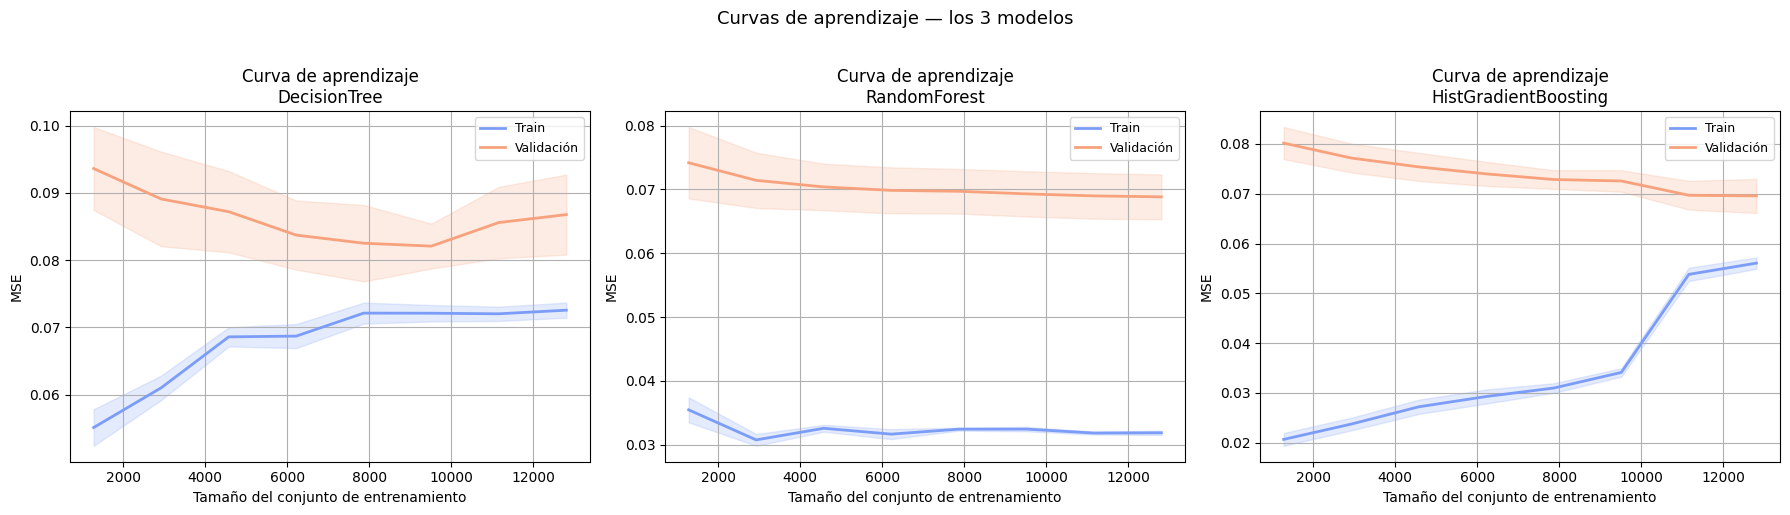

In [58]:
from sklearn.model_selection import learning_curve

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

modelos_lc = [
    ('DecisionTree', dt_val),
    ('RandomForest', rf_best),
    ('HistGradientBoosting', hgb_best),
]

train_sizes = np.linspace(0.1, 1.0, 8)

for ax, (nombre, modelo) in zip(axes, modelos_lc):
    train_sz, train_scores, val_scores = learning_curve(
        modelo, X, y,
        train_sizes=train_sizes,
        cv=KF,
        scoring='neg_mean_squared_error',
        n_jobs=-1,
    )

    # Convertir a MSE positivo
    train_mse = -train_scores
    val_mse   = -val_scores

    train_mean = train_mse.mean(axis=1)
    train_std  = train_mse.std(axis=1)
    val_mean   = val_mse.mean(axis=1)
    val_std    = val_mse.std(axis=1)

    ax.plot(train_sz, train_mean, color=P['blue'],   lw=2, label='Train')
    ax.fill_between(train_sz,
                    train_mean - train_std,
                    train_mean + train_std,
                    alpha=0.2, color=P['blue'])

    ax.plot(train_sz, val_mean, color=P['orange'], lw=2, label='Validación')
    ax.fill_between(train_sz,
                    val_mean - val_std,
                    val_mean + val_std,
                    alpha=0.2, color=P['orange'])

    ax.set_xlabel('Tamaño del conjunto de entrenamiento')
    ax.set_ylabel('MSE')
    ax.set_title(f'Curva de aprendizaje\n{nombre}')
    ax.legend(fontsize=9)
    ax.grid(True)

plt.suptitle('Curvas de aprendizaje — los 3 modelos', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

---
## 11. Análisis del modelo final

### 11.1 z_true vs z_pred

Modelo seleccionado: RandomForest
MSE validación:      0.070320


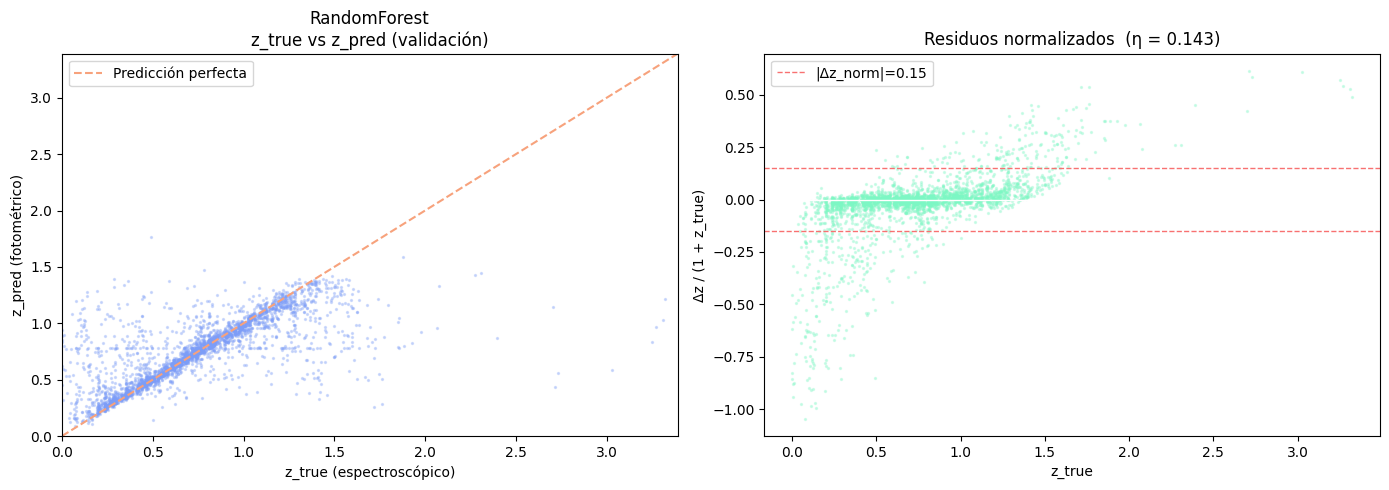

In [59]:
# Seleccionar automáticamente el mejor modelo según MSE de validación
candidatos = {
    'DecisionTree':         (dt_val,  pred_val_dt,  metrics_dt_val['MSE']),
    'RandomForest':         (rf_best, pred_val_rf,  metrics_rf_val['MSE']),
    'HistGradientBoosting': (hgb_best,pred_val_hgb, metrics_hgb_val['MSE']),
}

nombre_final, (modelo_final, pred_val_final, _) = min(
    candidatos.items(), key=lambda x: x[1][2]
)
print(f"Modelo seleccionado: {nombre_final}")
print(f"MSE validación:      {candidatos[nombre_final][2]:.6f}")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# z_true vs z_pred
ax = axes[0]
ax.scatter(y_val, pred_val_final, s=2, alpha=0.3, color=P['blue'], rasterized=True)
lims = [0, max(y_val.max(), pred_val_final.max()) * 1.02]
ax.plot(lims, lims, color=P['orange'], lw=1.5, linestyle='--', label='Predicción perfecta')
ax.set_xlim(lims); ax.set_ylim(lims)
ax.set_xlabel('z_true (espectroscópico)')
ax.set_ylabel('z_pred (fotométrico)')
ax.set_title(f'{nombre_final}\nz_true vs z_pred (validación)')
ax.legend()

# Residuos normalizados
ax = axes[1]
dz = (y_val.values - pred_val_final) / (1 + y_val.values)
ax.scatter(y_val, dz, s=2, alpha=0.3, color=P['green'], rasterized=True)
ax.axhline(0,     color='white',      lw=1.0)
ax.axhline(0.15,  color=P['red'],     lw=1.0, linestyle='--', label='|Δz_norm|=0.15')
ax.axhline(-0.15, color=P['red'],     lw=1.0, linestyle='--')
outlier_frac = (np.abs(dz) > 0.15).mean()
ax.set_xlabel('z_true')
ax.set_ylabel('Δz / (1 + z_true)')
ax.set_title(f'Residuos normalizados  (η = {outlier_frac:.3f})')
ax.legend()

plt.tight_layout()
plt.show()

### 11.2 Importancia de variables

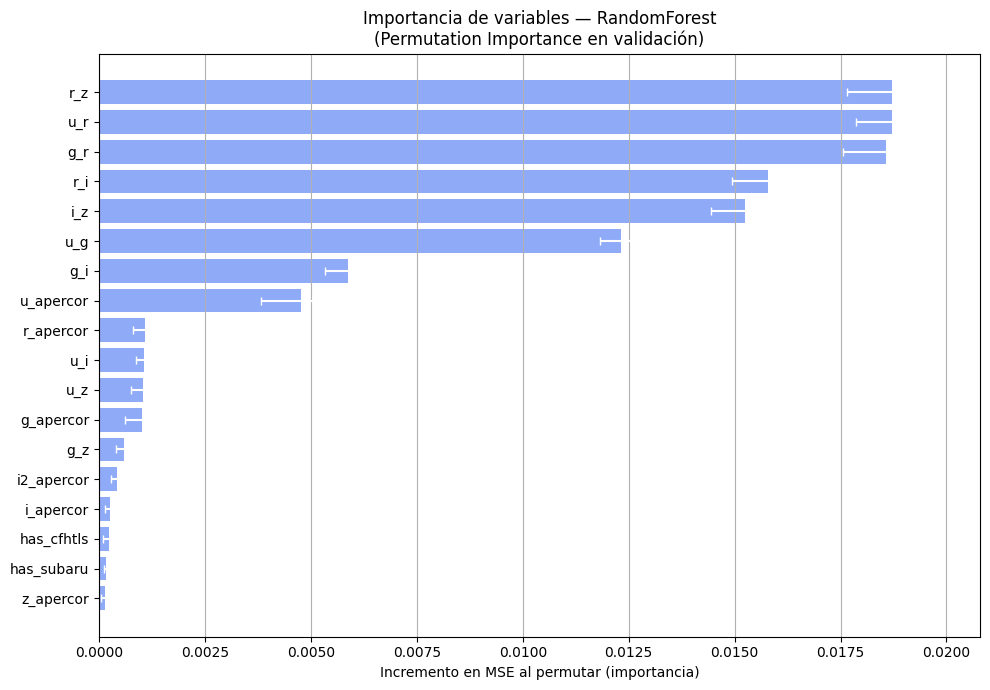

Top 10 features:
  feature  importance      std
      r_z    0.018724 0.001077
      u_r    0.018722 0.000851
      g_r    0.018575 0.001021
      r_i    0.015785 0.000844
      i_z    0.015255 0.000812
      u_g    0.012320 0.000502
      g_i    0.005874 0.000543
u_apercor    0.004761 0.000942
r_apercor    0.001076 0.000267
      u_i    0.001067 0.000189


In [60]:
# Para HGB usamos permutation importance (más confiable que impurity)
# Para RF podemos usar feature_importances_ directamente

perm = permutation_importance(
    modelo_final, X_val, y_val,
    n_repeats=10, random_state=SEED, n_jobs=-1,
    scoring='neg_mean_squared_error'
)

perm_df = pd.DataFrame({
    'feature':    FEATURES,
    'importance': perm.importances_mean,
    'std':        perm.importances_std,
}).sort_values('importance', ascending=False)

fig, ax = plt.subplots(figsize=(10, 7))
bars = ax.barh(perm_df['feature'][::-1], perm_df['importance'][::-1],
               xerr=perm_df['std'][::-1],
               color=P['blue'], edgecolor='none', alpha=0.85, ecolor='white', capsize=3)
ax.set_xlabel('Incremento en MSE al permutar (importancia)')
ax.set_title(f'Importancia de variables — {nombre_final}\n(Permutation Importance en validación)')
ax.grid(axis='x')
plt.tight_layout()
plt.show()

print("Top 10 features:")
print(perm_df.head(10).to_string(index=False))

### 11.3 Análisis de errores por rango de redshift

Error por rango de redshift:
            n      MSE  outliers
rango                           
0.0–0.3   431  0.10587   0.35499
0.3–0.6   779  0.01644   0.11553
0.6–0.9  1023  0.00326   0.04301
0.9–1.2   565  0.00427   0.04425
1.2–1.5   310  0.01994   0.24194
1.5+       89  0.08071   0.73034


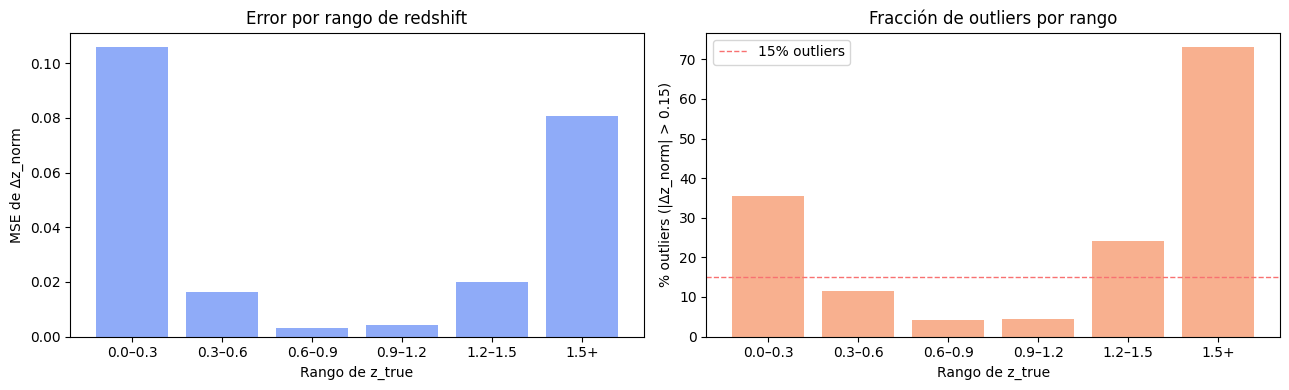

In [61]:
bins_z = [0, 0.3, 0.6, 0.9, 1.2, 1.5, 3.0]
labels_z = ['0.0–0.3','0.3–0.6','0.6–0.9','0.9–1.2','1.2–1.5','1.5+']

df_err = pd.DataFrame({
    'z_true': y_val.values,
    'z_pred': pred_val_final,
    'dz_norm': np.abs(dz),
})
df_err['rango'] = pd.cut(df_err['z_true'], bins=bins_z, labels=labels_z)

err_by_range = df_err.groupby('rango', observed=False).agg(
    n        = ('z_true', 'count'),
    MSE      = ('dz_norm', lambda x: (x**2).mean()),
    outliers = ('dz_norm', lambda x: (x > 0.15).mean()),
).round(5)

print("Error por rango de redshift:")
print(err_by_range)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

ax = axes[0]
ax.bar(labels_z, err_by_range['MSE'], color=P['blue'], edgecolor='none', alpha=0.85)
ax.set_xlabel('Rango de z_true')
ax.set_ylabel('MSE de Δz_norm')
ax.set_title('Error por rango de redshift')

ax = axes[1]
ax.bar(labels_z, err_by_range['outliers']*100, color=P['orange'], edgecolor='none', alpha=0.85)
ax.axhline(15, color=P['red'], lw=1, linestyle='--', label='15% outliers')
ax.set_xlabel('Rango de z_true')
ax.set_ylabel('% outliers (|Δz_norm| > 0.15)')
ax.set_title('Fracción de outliers por rango')
ax.legend()

plt.tight_layout()
plt.show()

---
## 12. Generación de predicciones

In [63]:
# Re-entrenar el modelo final con todo el training filtrado
modelo_final.fit(X, y)

# Generar predicciones sobre test
z_pred_test = modelo_final.predict(X_test)

print(f"Predicciones generadas: {len(z_pred_test)}")
print(f"Estadísticas predicciones: mean={z_pred_test.mean():.4f} "
      f"std={z_pred_test.std():.4f}  min={z_pred_test.min():.4f}  max={z_pred_test.max():.4f}")

# Crear archivo de entrega
predicciones = pd.DataFrame({
    'objno_deep2': df_test['objno_deep2'].values,
    'z_pred':      z_pred_test,
})

assert len(predicciones) == len(df_test), "Error en número de predicciones"
predicciones.to_csv('predicciones.csv', index=False)
print("\nArchivo predicciones.csv guardado.")
predicciones.head()

Predicciones generadas: 4765
Estadísticas predicciones: mean=0.7591 std=0.2846  min=0.0895  max=1.6660

Archivo predicciones.csv guardado.


,objno_deep2,z_pred
0,12011416,0.561879
1,12023279,0.822626
2,13017399,1.025451
3,12008131,0.462296
4,12003729,0.544225


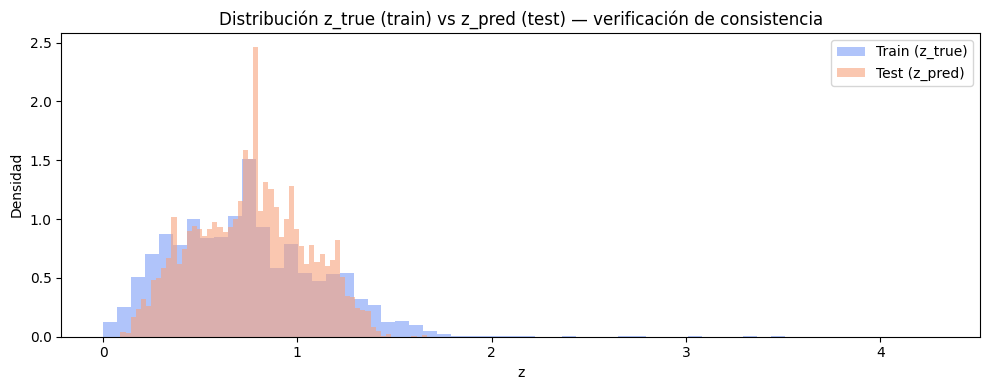

In [64]:
# Verificación visual: distribución predicciones test vs train
fig, ax = plt.subplots(figsize=(10, 4))

ax.hist(y, bins=60, alpha=0.6, color=P['blue'],   edgecolor='none', density=True, label='Train (z_true)')
ax.hist(z_pred_test, bins=60, alpha=0.6, color=P['orange'], edgecolor='none', density=True, label='Test (z_pred)')

ax.set_xlabel('z')
ax.set_ylabel('Densidad')
ax.set_title('Distribución z_true (train) vs z_pred (test) — verificación de consistencia')
ax.legend()
plt.tight_layout()
plt.show()

## 13. Preguntas finales

**1. ¿Qué modelo obtuvo el menor MSE en validación?**

> RandomForest obtuvo el menor MSE en validación con **0.070320**, seguido muy de cerca por HistGradientBoosting (0.070760) y finalmente DecisionTree (0.091936).

**2. ¿Ese modelo fue elegido como modelo final? Justifiquen.**

> Sí. RandomForest obtuvo el menor MSE de validación (0.070320) y además la mejor σ_NMAD (0.03281) y el menor η (0.1427) entre los tres modelos. Las tres métricas apuntan al mismo ganador, por lo que la elección es consistente.

**3. ¿Qué diferencias observaron entre un árbol individual y los métodos de ensamble?**

> El DecisionTree sin tunear obtuvo MSE train de 0.004851 vs MSE validación de 0.130169 — brecha enorme que evidencia overfit severo. Con tuning (max_depth=5) el MSE validación baja a 0.091936 pero sigue siendo considerablemente peor que los ensambles. RandomForest y HGB redujeron el MSE de validación en ~24% respecto al DT tuneado, con una brecha train/val mucho más controlada.

**4. ¿Qué variables parecen ser más importantes para predecir el redshift?**

> Los colores dominan completamente: `r_z` (0.01872), `u_r` (0.01872), `g_r` (0.01858), `r_i` (0.01579) e `i_z` (0.01526) son las 5 más importantes. Las magnitudes brutas (`r_apercor`, `u_apercor`) tienen importancia mucho menor. Los flags `has_cfhtls`, `has_subaru` y `z_apercor` son prácticamente irrelevantes.

**5. ¿En qué rangos de redshift falla más el modelo?**

> El modelo falla significativamente en dos extremos: z < 0.3 (MSE=0.106, η=35.5%) y z > 1.5 (MSE=0.081, η=73%). El rango con mejor desempeño es 0.6–0.9 (MSE=0.003, η=4.3%), que concentra la mayor parte de los objetos de entrenamiento. En z > 1.5 solo hay 89 objetos de validación, por lo que el modelo tiene muy pocos ejemplos para aprender ese régimen.

**6. ¿Qué posibles fuentes de error o sesgo puede tener este enfoque?**

> Primero, la imputación por mediana en bandas con centinela introduce sesgo en objetos no detectados. Segundo, el filtro zquality ≥ 2 excluye ~17% del training, que puede tener distribución fotométrica distinta. Tercero, el modelo interpola bien en el rango 0.6–1.2 donde hay datos abundantes, pero extrapola mal en los extremos (z<0.3, z>1.5) donde hay pocos ejemplos. Cuarto, las degenerencias de color — distintos tipos de galaxias a distintos redshifts pueden tener colores similares.

**7. ¿Qué decisión metodológica tuvo mayor impacto en el resultado final?**

> El feature engineering de colores fotométricos. Las magnitudes brutas tienen correlaciones individuales bajas con zhelio (~0.3), mientras que los colores `r_z`, `u_r` y `g_r` resultaron ser las features más importantes según Permutation Importance. Sin los colores, el modelo dependería de magnitudes absolutas que mezclan redshift con luminosidad intrínseca de la galaxia.

**8. ¿El modelo con menor MSE es necesariamente el mejor modelo desde el punto de vista científico?**

> No necesariamente. El MSE penaliza errores grandes cuadráticamente, lo que puede favorecer modelos que eviten outliers grandes pero sean sistemáticamente sesgados. En astronomía, σ_NMAD es preferida porque es robusta a outliers. En este caso RandomForest ganó en las tres métricas simultáneamente, pero en general un modelo con MSE ligeramente mayor pero η mucho menor podría ser más valioso científicamente, ya que los outliers fotométricos contaminan análisis cosmológicos como la función de correlación o la distribución de materia.


---
## 14. Conclusión

> El modelo final seleccionado es **RandomForestRegressor** con hiperparámetros `max_depth=20`, `max_features=0.7`, `min_samples_leaf=4`, `n_estimators=300`, entrenado sobre 18 features (6 magnitudes + 10 colores fotométricos + 2 flags de fuente) usando objetos con `zquality ≥ 2` y `zhelio ≥ 0`.
>
> Este modelo obtuvo el mejor desempeño en las tres métricas de validación: **MSE=0.0703**, **σ_NMAD=0.0328** y **η=0.1427**. Superó al DecisionTree baseline en un 24% en MSE de validación y fue marginalmente mejor que HistGradientBoosting (0.0703 vs 0.0708).
>
> Las variables más importantes fueron los colores fotométricos `r_z`, `u_r` y `g_r`, consistente con la física del problema: el corrimiento al rojo desplaza características espectrales de las galaxias a través de los filtros, haciendo que los colores sean más informativos que las magnitudes absolutas.
>
> El modelo falla principalmente en los extremos del rango de redshift: z < 0.3 (η=35.5%) y z > 1.5 (η=73%), donde la escasez de objetos de entrenamiento limita la capacidad predictiva. El rango 0.6–1.2 es donde el modelo generaliza mejor, con η < 5%.

Posdata: Gracias por la extensión de la entrega